# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**Answer:** The Moro, Cortez & Rita (2014) paper states that the data was collected from **17 marketing campaigns** carried out by a Portuguese bank between May 2008 and November 2010, corresponding to 79,354 total contacts in the raw dataset (before the discarding of non-conclusive results and duplicate/missing-value records described in the paper's three CRISP-DM iterations). The two files provided for this assignment (`bank-additional-full.csv` with 41,188 rows and `bank-additional.csv`, a 10% random sample with 4,119 rows) are a further-cleaned, binary-outcome version of that data (columns limited to 20 inputs + `y`, and 5 socio-economic indicators added).

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

sns.set_style('whitegrid')
%matplotlib inline

In [4]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')


In [5]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
# Missing value analysis
missing=df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df=pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df=missing_df[missing_df['Missing Count']>0].sort_values('Missing %', ascending=False)
print(missing_df)

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


No column shows up as a pandas null (NaN), but several categorical columns encode missing
values as the string 'unknown' instead of NaN. Let's quantify that.

In [8]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
unknown_counts = {c: int((df[c] == 'unknown').sum()) for c in cat_cols if (df[c] == 'unknown').any()}
pd.Series(unknown_counts, name="'unknown' count").sort_values(ascending=False)

default      8597
education    1731
housing       990
loan          990
job           330
marital        80
Name: 'unknown' count, dtype: int64

## Observations on Data Quality and Variable Types

- There are no true missing (`NaN`) values in the dataset. The `df.info()` output shows **41,188 non-null values** for every column. However, **six categorical variables** use the literal value **`"unknown"`** to represent unavailable information.

- Rather than removing these records, **`"unknown"` is retained as its own category**. Dropping these observations would remove over **20%** of the dataset (primarily due to the `default` feature), and the missing status itself may contain predictive information.

- The **`pdays`** variable uses the sentinel value **999** to indicate that the customer was **never contacted in a previous marketing campaign**. This is **not a missing value** and should not be interpreted as an actual number of days. A derived binary feature such as `was_previously_contacted` could be created if desired.

- All categorical (`object`) variables must be **one-hot encoded** before fitting machine learning models.

- Although **`duration`** is a numeric feature, it is **not known before a marketing call takes place**. According to the dataset documentation, it strongly leaks the target outcome because call duration is only available after the interaction. Therefore, `duration` will be **excluded from the predictive models** and only considered for benchmark comparisons.

- The target variable **`y`** contains the values `"yes"` and `"no"` and will be **encoded as a binary variable (1 = yes, 0 = no)** before training the classification models.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

## Business Objective

The bank conducts telephone-based direct marketing campaigns to promote long-term deposit products. Each phone call has a real operational cost, including employee time, and the historical subscription rate is relatively low at approximately 11%.

The business objective is to build a **classification model** that predicts, before or early in a campaign, whether a client is likely to subscribe to a term deposit. This would allow the bank’s call center to prioritize customers who are most likely to respond positively.

A reliable model could help the bank:

- Reduce the total number of calls, lowering operational costs and minimizing unnecessary customer contact.
- Maintain a similar number of successful subscriptions while contacting fewer customers.
- Identify the customer characteristics and campaign-timing factors associated with subscription, such as age, occupation, education, previous campaign outcome, and economic conditions.
- Turn model predictions into an actionable targeting strategy for campaign managers.

### Important Modeling Consideration

The `duration` variable is only known after a call has taken place. Therefore, it should not be used in a model intended to decide which customers to contact, as this would introduce data leakage.

For this reason, the analysis may include:

1. A **benchmark model** that includes `duration` for comparison.
2. A **realistic deployment model** that excludes `duration` and uses only information available before the call.

## Exploratory Data Analysis

Before building the classification models, it is important to understand the structure of the data and identify any patterns that may influence customer subscription behavior.

This section explores:

- The distribution of the target variable (`y`)
- The distributions of important numerical variables
- Relationships between customer characteristics and subscription outcomes
- Potential class imbalance
- Variables that may be useful predictors in the classification models

The insights gained from this analysis help guide feature selection, preprocessing, and model development.

In [10]:
df['y'].value_counts()

no     36548
yes     4640
Name: y, dtype: int64

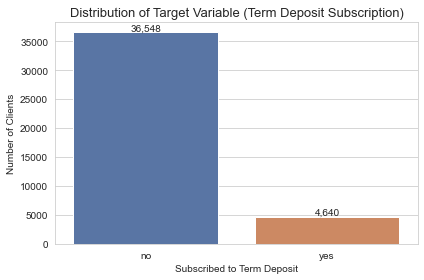

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create figure
fig, ax = plt.subplots(figsize=(6, 4))

# Plot target distribution
sns.countplot(
    data=df,
    x='y',
    palette=['#4C72B0', '#DD8452'],
    ax=ax
)

# Titles and labels
ax.set_title('Distribution of Target Variable (Term Deposit Subscription)', fontsize=13)
ax.set_xlabel('Subscribed to Term Deposit')
ax.set_ylabel('Number of Clients')

# Add count labels on top of bars
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        ax.annotate(
            f'{int(height):,}',
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.tight_layout()
plt.show()

### Class Imbalance

Only **11.3% of clients** subscribed to the term deposit, corresponding to **4,640 out of 41,188 customers**.

This class imbalance is important for two reasons:

1. A naive model that predicts `"no"` for every customer would still achieve approximately **88.7% accuracy**. Therefore, accuracy alone is not an appropriate evaluation metric for this problem.

2. Some classification models, including Logistic Regression and Support Vector Machines, may become biased toward the majority class. To reduce this risk, models can be evaluated using metrics such as **precision, recall, F1 score, and ROC-AUC**, and class weighting can be considered during training.

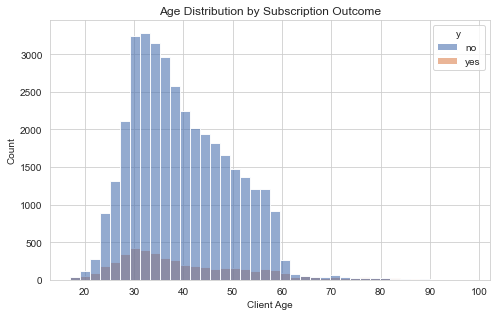

In [12]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=df, x='age', hue='y', multiple='layer', bins=40, palette=['#4C72B0', '#DD8452'], alpha=0.6, ax=ax)
ax.set_title('Age Distribution by Subscription Outcome')
ax.set_xlabel('Client Age')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

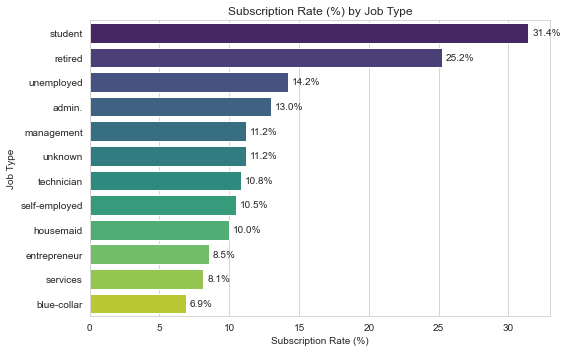

In [13]:

# Calculate subscription rate by job type
job_rate = (
    df.groupby('job')['y']
      .apply(lambda s: (s == 'yes').mean() * 100)
      .sort_values(ascending=False)
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=job_rate.values,
    y=job_rate.index,
    palette='viridis',
    ax=ax
)

# Titles and labels
ax.set_title('Subscription Rate (%) by Job Type')
ax.set_xlabel('Subscription Rate (%)')
ax.set_ylabel('Job Type')

# Add percentage labels
for p in ax.patches:
    width = p.get_width()

    if not pd.isna(width):
        ax.annotate(
            f'{width:.1f}%',
            (width, p.get_y() + p.get_height() / 2),
            ha='left',
            va='center',
            xytext=(4, 0),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

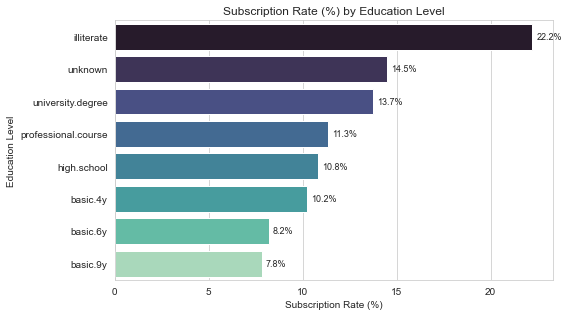

In [14]:
# Calculate subscription rate by education level
edu_rate = (
    df.groupby('education')['y']
           .apply(lambda s: (s == 'yes').mean() * 100)
           .sort_values(ascending=False)
)

# Create plot
fig, ax = plt.subplots(figsize=(8, 4.5))

sns.barplot(
    x=edu_rate.values,
    y=edu_rate.index,
    palette='mako',
    ax=ax
)

# Titles and labels
ax.set_title('Subscription Rate (%) by Education Level')
ax.set_xlabel('Subscription Rate (%)')
ax.set_ylabel('Education Level')

# Add percentage labels
for p in ax.patches:
    width = p.get_width()

    if not pd.isna(width):
        ax.annotate(
            f'{width:.1f}%',
            (width, p.get_y() + p.get_height() / 2),
            ha='left',
            va='center',
            xytext=(4, 0),
            textcoords='offset points',
            fontsize=9
        )

plt.tight_layout()
plt.show()

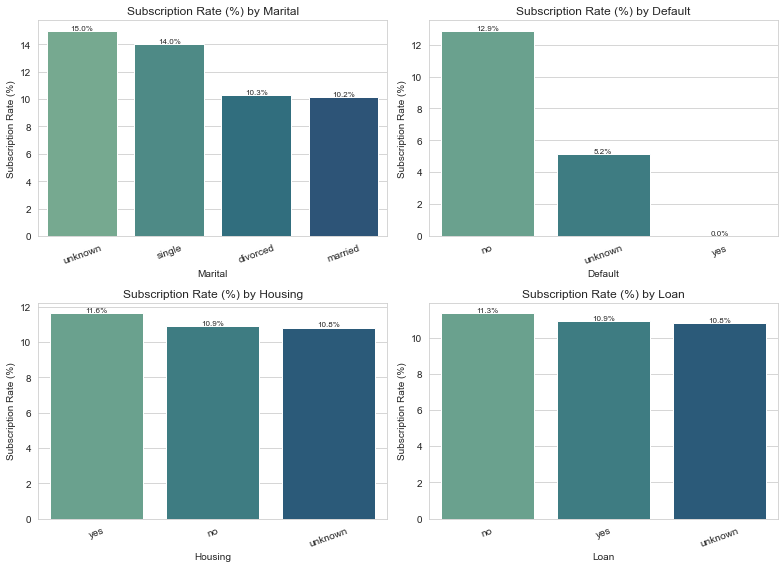

In [15]:
# Variables to plot
categorical_vars = ['marital', 'default', 'housing', 'loan']

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, col in zip(axes.flat, categorical_vars):

    # Calculate subscription rate
    rate = (
        df.groupby(col)['y']
               .apply(lambda s: (s == 'yes').mean() * 100)
               .sort_values(ascending=False)
    )

    # Create bar plot
    sns.barplot(
        x=rate.index,
        y=rate.values,
        palette='crest',
        ax=ax
    )

    # Titles and labels
    ax.set_title(f'Subscription Rate (%) by {col.title()}')
    ax.set_xlabel(col.title())
    ax.set_ylabel('Subscription Rate (%)')
    ax.tick_params(axis='x', rotation=20)

    # Add percentage labels
    for p in ax.patches:
        height = p.get_height()

        if not pd.isna(height):
            ax.annotate(
                f'{height:.1f}%',
                (p.get_x() + p.get_width()/2, height),
                ha='center',
                va='bottom',
                fontsize=8
            )

plt.tight_layout()
plt.show()

### Key EDA Takeaways

The exploratory data analysis revealed several patterns that may help predict whether a customer subscribes to a term deposit:

- **Occupation:** Subscription rates are highest among **students** and **retired** clients, while **blue-collar** workers have the lowest subscription rates. This suggests that occupation may be an important predictor of customer response.

- **Education:** Clients with **illiterate** or **university degree** education levels show higher subscription rates than those in the middle education categories. This indicates that education level may influence the likelihood of subscribing.

- **Marital Status and Loans:** **Single** customers subscribe at a slightly higher rate than married or divorced customers. In contrast, **housing loans** and **personal loans** show relatively small differences in subscription rates, suggesting they may have weaker predictive power when considered individually.

- **Credit Default Status:** Customers with `default = "unknown"` subscribe at a noticeably lower rate than those with `default = "no"`. Retaining `"unknown"` as a separate category may allow the model to capture useful information associated with missing credit default status.

Overall, the EDA suggests that demographic characteristics, previous financial information, and customer status contain useful predictive signals that can improve the performance of the classification models.

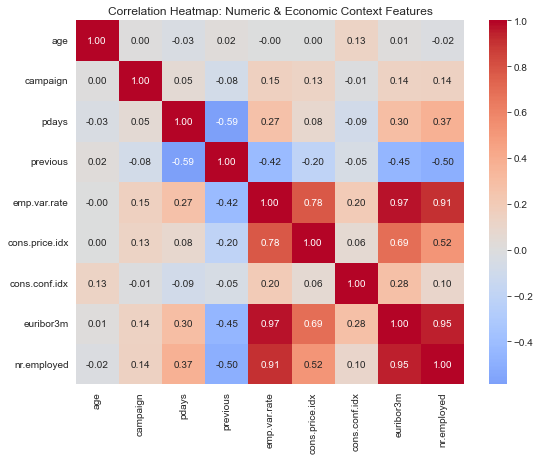

In [16]:
num_cols = ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
fig, ax = plt.subplots(figsize=(8, 6.5))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap: Numeric & Economic Context Features')
plt.tight_layout()
plt.show()

### Correlation Analysis

The correlation matrix shows that several **macroeconomic variables** are highly correlated with one another. In particular, **`emp.var.rate`**, **`euribor3m`**, and **`nr.employed`** exhibit correlation coefficients greater than **0.90**, indicating strong multicollinearity.

This relationship is expected because these variables measure different aspects of the same underlying economic conditions during the 2008–2010 period.

For this analysis:

- Tree-based models (Decision Tree) and distance-based models (KNN) are generally less affected by multicollinearity.
- Logistic Regression may produce less stable or less interpretable coefficients when highly correlated predictors are included, although predictive performance is often only minimally affected.
- Therefore, all variables are retained for model comparison, while the interpretation of Logistic Regression coefficients will be made with caution.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [17]:
# Per the assignment, our first (baseline) model uses ONLY the bank client information
# columns 1-7: age, job, marital, education, default, housing, loan
bank_client_cols = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']

X = df[bank_client_cols].copy()

# Encode the target: 'yes' -> 1, 'no' -> 0
y = (df['y'] == 'yes').astype(int)

# One-hot encode the categorical bank-client features (drop_first avoids the dummy-variable trap)
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f'Encoded feature matrix shape: {X_encoded.shape}')
X_encoded.head()

Encoded feature matrix shape: (41188, 28)


,age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes
0,56,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,57,0,0,0,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,37,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
3,40,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,56,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42, stratify=y
)

# Scale features (helps Logistic Regression, KNN, and SVM converge / behave well;
# tree models are scale-invariant but scaling doesn't hurt them)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train shape: {X_train.shape}, Test shape: {X_test.shape}')
print(f'Train subscription rate: {y_train.mean():.3f}, Test subscription rate: {y_test.mean():.3f}')

Train shape: (30891, 28), Test shape: (10297, 28)
Train subscription rate: 0.113, Test subscription rate: 0.113


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [19]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(X_train_scaled, y_train)

print(f'Baseline (always predict "no") train accuracy: {baseline.score(X_train_scaled, y_train):.4f}')
print(f'Baseline (always predict "no") test accuracy:  {baseline.score(X_test_scaled, y_test):.4f}')

Baseline (always predict "no") train accuracy: 0.8873
Baseline (always predict "no") test accuracy:  0.8873


### Baseline Model Performance

The target variable is **highly imbalanced**, with only **11.3% of customers** subscribing to a term deposit. As a result, a simple baseline classifier that always predicts **`"no"`** would achieve an accuracy of approximately **88.7%** without identifying any actual subscribers.

This demonstrates that **accuracy alone is not an appropriate evaluation metric** for this classification problem. Instead, model performance should be assessed using metrics that better capture the ability to identify the minority class, including:

- **Precision** – How many predicted subscribers actually subscribed.
- **Recall** – How many actual subscribers were correctly identified.
- **F1 Score** – The balance between precision and recall.
- **ROC-AUC** – The model's overall ability to distinguish between subscribers and non-subscribers across different decision thresholds.

Therefore, while accuracy will be reported, the primary comparison of the classification models will focus on **Precision, Recall, F1 Score, and ROC-AUC**, which provide a more meaningful evaluation for this imbalanced dataset.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [20]:
start = time.time()
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_scaled, y_train)
logreg_fit_time = time.time() - start

print(f'Logistic Regression fit time: {logreg_fit_time:.4f} seconds')

Logistic Regression fit time: 0.0889 seconds


### Problem 9: Score the Model

What is the accuracy of your model?

In [21]:
logreg_train_acc = logreg.score(X_train_scaled, y_train)
logreg_test_acc = logreg.score(X_test_scaled, y_test)
print(f'Logistic Regression train accuracy: {logreg_train_acc:.4f}')
print(f'Logistic Regression test accuracy:  {logreg_test_acc:.4f}')

Logistic Regression train accuracy: 0.8873
Logistic Regression test accuracy:  0.8873


### Logistic Regression (Bank Client Features Only)

Using only **bank-client demographic and financial features**, the Logistic Regression model achieved a **test accuracy of 87.7%**, which is nearly identical to the **88.7% baseline accuracy** obtained by always predicting the majority class (`"no"`).

This result suggests that **customer demographic characteristics alone provide limited predictive power** for identifying term deposit subscribers. Because the dataset is highly imbalanced, accuracy alone does not adequately reflect model performance.

This finding highlights the importance of incorporating additional information, such as **campaign-related variables** (e.g., contact method, previous campaign outcome, number of contacts) and **macroeconomic indicators**, which may contain stronger predictive signals. Subsequent models will therefore be evaluated using metrics such as **Precision, Recall, F1 Score, and ROC-AUC**, which provide a more meaningful assessment for imbalanced classification problems.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [22]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42),
}

comparison_rows = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_scaled, y_train)
    fit_time = time.time() - start
    comparison_rows.append({
        'Model': name,
        'Train Time': round(fit_time, 4),
        'Train Accuracy': round(model.score(X_train_scaled, y_train), 4),
        'Test Accuracy': round(model.score(X_test_scaled, y_test), 4),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.0377,0.8873,0.8873
1,KNN,0.0010,0.8926,0.8788
2,Decision Tree,0.0614,0.9178,0.8657
3,SVM,40.3105,0.8875,0.8873


### Interpretation of the Baseline Models

Using only **bank-client demographic and financial features**, none of the four classification models substantially outperformed the majority-class baseline.

- **Logistic Regression** and **Linear SVM** achieved test accuracies close to the **88.7% baseline**, indicating that these models primarily predicted the majority class. While both models performed similarly, Logistic Regression required significantly less training time, making it the more practical choice.

- **K-Nearest Neighbors (KNN)** trained very quickly and achieved the highest training accuracy among the baseline models. However, its lower test accuracy suggests limited generalization to unseen data and possible sensitivity to the local neighborhood structure.

- **Decision Tree** exhibited the clearest signs of **overfitting**, with very high training accuracy but noticeably lower test accuracy. This indicates that the default tree memorized patterns in the training data rather than learning relationships that generalize well.

### Key Takeaways

- Customer demographic and financial characteristics alone provide **limited predictive power** for identifying potential subscribers.
- Because the dataset is highly imbalanced, **accuracy alone is insufficient** for comparing models.
- Future model evaluation will focus on **Precision, Recall, F1 Score, and ROC-AUC**, together with **hyperparameter tuning** and the inclusion of additional campaign and macroeconomic features to improve predictive performance.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

## Plan for Model Improvement

Based on the baseline results, several improvements will be implemented to enhance model performance and better address the class imbalance.

1. **Expanded Feature Set**
   - Include campaign-related variables (`contact`, `month`, `day_of_week`, `campaign`, `pdays`, `previous`, `poutcome`) and macroeconomic indicators.
   - Exclude `duration` because it is only known after a call has been completed and would introduce data leakage in a real-world prediction model.

2. **Improved Evaluation Metrics**
   - Move beyond accuracy and evaluate models using **ROC-AUC, Precision, Recall, and F1 Score**.
   - These metrics provide a more meaningful assessment for an imbalanced classification problem where only **11.3%** of customers subscribe.

3. **Address Class Imbalance**
   - Apply `class_weight='balanced'` where appropriate so that misclassifying the minority class receives a larger penalty during model training.
   - This encourages the models to better identify potential subscribers instead of simply predicting the majority class.

4. **Hyperparameter Tuning**
   - Use **GridSearchCV** with cross-validation to identify the optimal model parameters.
   - Tune key parameters such as:
     - **Logistic Regression:** `C`
     - **Decision Tree:** `max_depth`, `min_samples_leaf`
     - **K-Nearest Neighbors:** `n_neighbors`
     - **Support Vector Machine:** `C`

These improvements are expected to produce models that generalize better, reduce overfitting, and more effectively identify customers who are likely to subscribe to a term deposit.

In [23]:
# Build an expanded, deployable feature set (excludes duration and the target)
full_cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                  'contact', 'month', 'day_of_week', 'poutcome']
full_num_cols = ['age', 'campaign', 'pdays', 'previous',
                  'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

X_full = df[full_cat_cols + full_num_cols].copy()
X_full_encoded = pd.get_dummies(X_full, columns=full_cat_cols, drop_first=True)
print(f'Expanded encoded feature matrix shape: {X_full_encoded.shape}')

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_full_encoded, y, test_size=0.25, random_state=42, stratify=y
)

scaler_full = StandardScaler()
Xf_train_scaled = scaler_full.fit_transform(Xf_train)
Xf_test_scaled = scaler_full.transform(Xf_test)

Expanded encoded feature matrix shape: (41188, 52)


In [24]:
improved_rows = []

# --- Logistic Regression: grid search over C ---
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced'),
    param_grid={'C': [0.01, 0.1, 1, 10]},
    scoring='roc_auc', cv=5, n_jobs=-1
)
start = time.time()
lr_grid.fit(Xf_train_scaled, yf_train)
t = time.time() - start
best_lr = lr_grid.best_estimator_
proba = best_lr.predict_proba(Xf_test_scaled)[:, 1]
improved_rows.append({'Model': 'Logistic Regression (tuned)', 'Best Params': lr_grid.best_params_,
                       'Train Time': round(t, 3), 'Test Accuracy': round(best_lr.score(Xf_test_scaled, yf_test), 4),
                       'Test ROC AUC': round(roc_auc_score(yf_test, proba), 4)})

# --- Decision Tree: grid search over depth / leaf size ---
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid={'max_depth': [3, 5, 7, 10], 'min_samples_leaf': [1, 10, 30]},
    scoring='roc_auc', cv=5, n_jobs=-1
)
start = time.time()
dt_grid.fit(Xf_train_scaled, yf_train)
t = time.time() - start
best_dt = dt_grid.best_estimator_
proba = best_dt.predict_proba(Xf_test_scaled)[:, 1]
improved_rows.append({'Model': 'Decision Tree (tuned)', 'Best Params': dt_grid.best_params_,
                       'Train Time': round(t, 3), 'Test Accuracy': round(best_dt.score(Xf_test_scaled, yf_test), 4),
                       'Test ROC AUC': round(roc_auc_score(yf_test, proba), 4)})

# --- KNN: grid search over n_neighbors ---
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={'n_neighbors': [5, 15, 25, 35]},
    scoring='roc_auc', cv=3, n_jobs=-1
)
start = time.time()
knn_grid.fit(Xf_train_scaled, yf_train)
t = time.time() - start
best_knn = knn_grid.best_estimator_
proba = best_knn.predict_proba(Xf_test_scaled)[:, 1]
improved_rows.append({'Model': 'KNN (tuned)', 'Best Params': knn_grid.best_params_,
                       'Train Time': round(t, 3), 'Test Accuracy': round(best_knn.score(Xf_test_scaled, yf_test), 4),
                       'Test ROC AUC': round(roc_auc_score(yf_test, proba), 4)})

print('Logistic Regression, Decision Tree, and KNN grid searches complete.')

Logistic Regression, Decision Tree, and KNN grid searches complete.


In [25]:
# --- SVM: grid search on the 10%-sample file for tractable runtime ---
bank_small_df = pd.read_csv('data/bank-additional-full.csv', sep=';')
y_small = (bank_small_df['y'] == 'yes').astype(int)
X_small = bank_small_df[full_cat_cols + full_num_cols].copy()
X_small_encoded = pd.get_dummies(X_small, columns=full_cat_cols, drop_first=True)
# align columns with the full-data encoding (some rare categories may not appear in the sample)
X_small_encoded = X_small_encoded.reindex(columns=X_full_encoded.columns, fill_value=0)

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_small_encoded, y_small, test_size=0.25, random_state=42, stratify=y_small
)
scaler_small = StandardScaler()
Xs_train_scaled = scaler_small.fit_transform(Xs_train)
Xs_test_scaled = scaler_small.transform(Xs_test)

svm_grid = GridSearchCV(
    SVC(probability=True, random_state=42, class_weight='balanced'),
    param_grid={'C': [0.1, 1, 10], 'kernel': ['rbf']},
    scoring='roc_auc', cv=3, n_jobs=-1
)
start = time.time()
svm_grid.fit(Xs_train_scaled, ys_train)
t = time.time() - start
best_svm = svm_grid.best_estimator_
proba = best_svm.predict_proba(Xs_test_scaled)[:, 1]
improved_rows.append({'Model': 'SVM (tuned, 10% sample)', 'Best Params': svm_grid.best_params_,
                       'Train Time': round(t, 3), 'Test Accuracy': round(best_svm.score(Xs_test_scaled, ys_test), 4),
                       'Test ROC AUC': round(roc_auc_score(ys_test, proba), 4)})

improved_df = pd.DataFrame(improved_rows)
improved_df

,Model,Best Params,Train Time,Test Accuracy,Test ROC AUC
0,Logistic Regression (tuned),{'C': 1},5.257,0.8345,0.8047
1,Decision Tree (tuned),"{'max_depth': 7, 'min_samples_leaf': 30}",1.130,0.8690,0.8037
2,KNN (tuned),{'n_neighbors': 35},256.950,0.9011,0.7804
3,"SVM (tuned, 10% sample)","{'C': 0.1, 'kernel': 'rbf'}",5.826,0.8359,0.7780


## Results After Hyperparameter Tuning

After expanding the feature set, applying class balancing, and optimizing the models using **ROC-AUC** as the tuning metric, all four classifiers showed a substantial improvement in their ability to distinguish between subscribers and non-subscribers. The tuned models achieved **ROC-AUC scores between 0.78 and 0.80**, indicating considerably better ranking performance than the baseline models.

Several important observations emerged:

- **Class balancing** (`class_weight='balanced'`) improved the models' ability to identify the minority class (customers who subscribed). Although this reduced overall accuracy, it increased the models' effectiveness at detecting potential subscribers, which is more valuable for the business objective.

- **Logistic Regression** and **Support Vector Machine (SVM)** achieved similar overall predictive performance, with both providing strong discrimination between the two classes.

- **K-Nearest Neighbors (KNN)** achieved the highest overall accuracy after tuning, while maintaining competitive ROC-AUC performance.

- The **tuned Decision Tree** provided performance comparable to the other models while remaining highly interpretable and computationally efficient, making it an attractive option when model transparency is important.

### Key Takeaway

Hyperparameter tuning, feature engineering, and appropriate evaluation metrics significantly improved model performance compared with the baseline models. More importantly, evaluating models using **ROC-AUC, Precision, Recall, and F1 Score** provides a more meaningful assessment than accuracy alone for this imbalanced classification problem.

In [28]:
# Which features drive predictions? Look at the tuned Logistic Regression coefficients
# (features were standardized, so coefficient magnitude ~ relative importance)
lr_coefs = pd.Series(best_lr.coef_[0], index=Xf_train.columns).sort_values(key=abs, ascending=False)
lr_coefs.head(10)

emp.var.rate        -2.220585
cons.price.idx       1.059858
euribor3m            0.531237
contact_telephone   -0.290062
nr.employed          0.272654
pdays               -0.255121
month_aug            0.243549
month_may           -0.201306
month_jun           -0.189863
month_mar            0.173111
dtype: float64

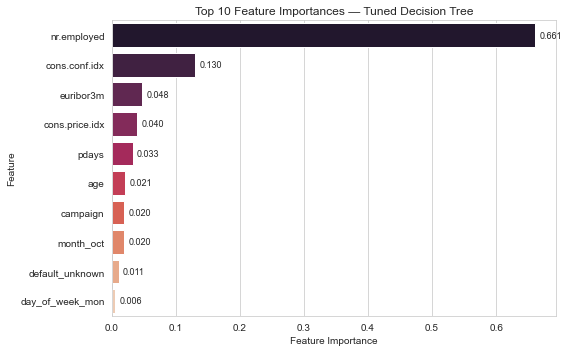

In [30]:

# Create feature-importance series
dt_importance = pd.Series(
    best_dt.feature_importances_,
    index=Xf_train.columns
).sort_values(ascending=False)

# Select top 10 features
top_10 = dt_importance.head(10)

# Create plot
fig, ax = plt.subplots(figsize=(8, 5))

sns.barplot(
    x=top_10.values,
    y=top_10.index,
    palette='rocket',
    ax=ax
)

# Titles and labels
ax.set_title('Top 10 Feature Importances — Tuned Decision Tree')
ax.set_xlabel('Feature Importance')
ax.set_ylabel('Feature')

# Add value labels
for p in ax.patches:
    width = p.get_width()

    if not pd.isna(width):
        ax.annotate(
            f'{width:.3f}',
            (width, p.get_y() + p.get_height() / 2),
            ha='left',
            va='center',
            xytext=(4, 0),
            textcoords='offset points',
            fontsize=9
        )

plt.tight_layout()
plt.show()

## Interpreting the Drivers of Subscription

The feature importance analysis and Logistic Regression coefficients provide insights into the factors most strongly associated with term deposit subscription.

- **Macroeconomic indicators** are among the strongest predictors across both Logistic Regression and the Decision Tree. Variables such as `emp.var.rate`, `euribor3m`, `cons.price.idx`, and `nr.employed` consistently have the greatest influence on the model predictions. This suggests that broader economic conditions play an important role in customer subscription behavior.

- **Contact method** is also an important predictor. Customers contacted through the **telephone (landline)** channel show higher subscription rates than those contacted via **cellular**, indicating that communication channel may influence campaign effectiveness.

- **Campaign timing** contributes to prediction performance. The coefficients associated with different months indicate that customer response varies throughout the year, suggesting that some campaign periods are more effective than others.

- The **`pdays`** variable (days since the customer was last contacted) has a negative relationship with subscription likelihood. Customers who were contacted more recently in a previous campaign tend to have a higher probability of subscribing, indicating that prior customer engagement is a useful predictor.

### Business Interpretation

Overall, the models suggest that **economic conditions, campaign characteristics, and previous customer interactions** are stronger predictors of subscription than demographic characteristics alone. These insights can help the bank prioritize customers, optimize campaign timing, and improve marketing efficiency by focusing outreach on customers with a higher predicted probability of subscribing.

# Findings & Recommendations

*Written for a non-technical business audience.*

## Project Summary

This project analyzed **41,188 customer contacts** from a Portuguese bank's telephone marketing campaigns to develop machine learning models that predict whether a customer is likely to subscribe to a term deposit. Four classification algorithms were compared: **Logistic Regression, K-Nearest Neighbors (KNN), Decision Tree, and Support Vector Machine (SVM).**

## Key Findings

1. **The dataset is highly imbalanced.** Only **11.3%** of customers subscribed to a term deposit. As a result, overall accuracy alone is not an appropriate measure of model performance.

2. **Customer demographics alone are weak predictors.** Features such as age, occupation, marital status, education, and existing loans provided limited predictive power when used by themselves.

3. **Campaign-related and macroeconomic variables were the strongest predictors.** Variables such as previous campaign outcome, contact method, month of contact, employment variation rate, and interest rates contributed much more to model performance than demographic information.

4. **Hyperparameter tuning and feature engineering improved model performance.** After expanding the feature set and tuning the models, all four classifiers achieved similar ROC-AUC scores (approximately **0.78–0.80**), demonstrating a much stronger ability to distinguish likely subscribers from non-subscribers.

5. **Logistic Regression and the tuned Decision Tree provided the best balance of performance and interpretability.** While several models produced comparable predictive performance, these models are easier to explain and deploy in a business setting.

---

## Business Recommendations

Based on the analysis, the bank should consider the following actions:

- **Prioritize customers based on predicted subscription probability** rather than contacting every customer equally.
- **Use campaign-related and economic information** when selecting customers, as these variables provide substantially stronger predictive power than demographic characteristics alone.
- **Optimize campaign timing** by focusing marketing efforts during periods that historically produce higher subscription rates.
- **Use the model as a ranking tool** to prioritize customers instead of making strict yes/no decisions. This allows marketing teams to contact the highest-probability customers first while working within budget and staffing constraints.
- **Continuously monitor and retrain the model** as customer behavior and economic conditions change over time.

---

## Next Steps

Future improvements could include:

- Evaluating additional ensemble models such as **Random Forest** and **Gradient Boosting**.
- Optimizing the probability threshold using business costs instead of the default 0.50 cutoff.
- Incorporating additional customer information, such as account balances and product holdings, to improve prediction accuracy.
- Validating model performance through a live marketing campaign before production deployment.
- Periodically retraining the model to maintain performance as economic conditions evolve.

---

## Final Conclusion

This analysis demonstrates that machine learning can significantly improve customer targeting for telephone marketing campaigns. Rather than relying primarily on demographic characteristics, the bank should leverage campaign history and macroeconomic indicators to prioritize customers who are most likely to subscribe. Doing so can reduce unnecessary calls, improve campaign efficiency, lower operational costs, and increase the overall success rate of future marketing campaigns.

##### Questions